#Step 1 Mapeo origen fuente de datos

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Step 2 Importanto librerias

Aquí, importamos Image de PIL para trabajar con la imagen, openpyxl para manipular archivos de Excel y PatternFill para aplicar colores a las celdas de Excel.

In [ ]:
# Importar las bibliotecas necesarias
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill

# Step 3 Funcion para procesar Imagen

Esta línea define la función image_to_excel con tres argumentos: image_path (ruta de la imagen JPG), excel_path (ruta del archivo Excel a guardar) y scale (factor de escala para la imagen, por defecto es 1, es decir, sin cambio de escala).

In [2]:
# Función para procesar la imagen
def procesar_imagen(ruta_imagen, tamano_maximo):
    # Cargar la imagen y redimensionar si es necesario
    with Image.open(ruta_imagen) as img:
        img.thumbnail(tamano_maximo)  # Redimensionar la imagen
        pixeles = list(img.getdata())  # Obtener los datos de los píxeles
        ancho, alto = img.size         # Obtener las dimensiones de la imagen
    return pixeles, ancho, alto       # Devolver los píxeles y dimensiones

In [3]:
# Función para crear y llenar la hoja de Excel
def crear_hoja_excel(pixeles, ancho, alto):
    wb = openpyxl.Workbook()          # Crear un nuevo libro de trabajo
    hoja = wb.active                  # Obtener la hoja activa

    # Recorrer los píxeles y aplicar el color a cada celda
    for y in range(alto):
        for x in range(ancho):
            color = pixeles[x + y * ancho]                       # Obtener el color RGB
            color_hex = f"{color[0]:02x}{color[1]:02x}{color[2]:02x}"  # Convertir a hex
            celda = hoja.cell(row=y + 1, column=x + 1)           # Obtener la celda
            celda.fill = PatternFill(start_color=color_hex, end_color=color_hex, fill_type="solid")

    return wb  # Devolver el libro de trabajo

# Función principal
def main():
    # Actualiza esta ruta a la ubicación de tu imagen en Google Drive
    ruta_imagen = "/content/drive/MyDrive/Colab Notebooks/Stitch_(Lilo_&_Stitch).svg.png"  # Ejemplo: "/content/drive/MyDrive/Colab Notebooks/Stitch_(Lilo_&_Stitch).svg.png"
    tamano_maximo = (50, 50)

    pixeles, ancho, alto = procesar_imagen(ruta_imagen, tamano_maximo)
    wb = crear_hoja_excel(pixeles, ancho, alto)

    # Guardar el archivo de Excel en Google Drive
    ruta_guardado = "/content/drive/MyDrive/Colab Notebooks/Stitch_(Lilo_&_Stitch).svg.png"  # Ejemplo: "/content/drive/MyDrive/Colab Notebooks/Stitch_(Lilo_&_Stitch).svg.png"
    wb.save(ruta_guardado)

if __name__ == "__main__":
    main()


NameError: name 'Image' is not defined

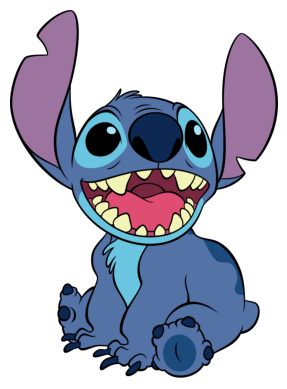

In [4]:
# prompt: quiero plotear la imagen que acabamos de procesar

from PIL import Image
import matplotlib.pyplot as plt

def mostrar_imagen(ruta_imagen):
    try:
        img = Image.open(ruta_imagen)
        plt.imshow(img)
        plt.axis('off')  # Ocultar ejes
        plt.show()
    except FileNotFoundError:
        print(f"Error: Archivo no encontrado en {ruta_imagen}")
    except Exception as e:
        print(f"Error al mostrar la imagen: {e}")

# Ejemplo de uso (reemplaza con la ruta correcta de tu imagen)
ruta_imagen = "/content/drive/MyDrive/Colab Notebooks/Stitch_(Lilo_&_Stitch).svg.png"
mostrar_imagen(ruta_imagen)


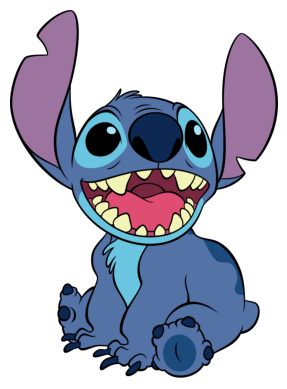

In [5]:
# prompt: ahora quiero ver esta imagen en Pixeles que representa el output de nuestro scritp

import matplotlib.pyplot as plt
def mostrar_imagen(ruta_imagen):
    try:
        img = Image.open(ruta_imagen)
        plt.imshow(img)
        plt.axis('off')  # Ocultar ejes
        plt.show()
    except FileNotFoundError:
        print(f"Error: Archivo no encontrado en {ruta_imagen}")
    except Exception as e:
        print(f"Error al mostrar la imagen: {e}")

# Ejemplo de uso (reemplaza con la ruta correcta de tu imagen)
ruta_imagen = "/content/drive/MyDrive/Colab Notebooks/Stitch_(Lilo_&_Stitch).svg.png"
mostrar_imagen(ruta_imagen)


In [6]:
# prompt: como puedo tener un resultado con menos pixeles?

from google.colab import drive
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill
import matplotlib.pyplot as plt

# Mount Google Drive
drive.mount('/content/drive')

def procesar_imagen(ruta_imagen, tamano_maximo):
    with Image.open(ruta_imagen) as img:
        img.thumbnail(tamano_maximo)
        pixeles = list(img.getdata())
        ancho, alto = img.size
    return pixeles, ancho, alto

def crear_hoja_excel(pixeles, ancho, alto):
    wb = openpyxl.Workbook()
    hoja = wb.active
    for y in range(alto):
        for x in range(ancho):
            color = pixeles[x + y * ancho]
            color_hex = f"{color[0]:02x}{color[1]:02x}{color[2]:02x}"
            celda = hoja.cell(row=y + 1, column=x + 1)
            celda.fill = PatternFill(start_color=color_hex, end_color=color_hex, fill_type="solid")
    return wb

def main():
    ruta_imagen = "/content/drive/MyDrive/Colab Notebooks/Stitch_(Lilo_&_Stitch).svg.png"
    # Reduce the size for fewer pixels in the output Excel file
    tamano_maximo = (20, 20)  # Example: 20x20 pixels

    pixeles, ancho, alto = procesar_imagen(ruta_imagen, tamano_maximo)
    wb = crear_hoja_excel(pixeles, ancho, alto)

    ruta_guardado = "/content/drive/MyDrive/Colab Notebooks/Stitch_(Lilo_&_Stitch).svg.png"
    wb.save(ruta_guardado)

if __name__ == "__main__":
    main()

def mostrar_imagen(ruta_imagen):
    try:
        img = Image.open(ruta_imagen)
        plt.imshow(img)
        plt.axis('off')
        plt.show()
    except FileNotFoundError:
        print(f"Error: Archivo no encontrado en {ruta_imagen}")
    except Exception as e:
        print(f"Error al mostrar la imagen: {e}")

ruta_imagen = "/content/drive/MyDrive/Colab Notebooks/Stitch_(Lilo_&_Stitch).svg.png"
mostrar_imagen(ruta_imagen)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Error al mostrar la imagen: cannot identify image file '/content/drive/MyDrive/Colab Notebooks/Stitch_(Lilo_&_Stitch).svg.png'


In [7]:
# Step 1 Mapeo origen fuente de datos
from google.colab import drive
drive.mount('/content/drive')

# Step 2 Importando librerías
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill
import os

# Función para procesar la imagen
def procesar_imagen(ruta_imagen, tamano_maximo=None):
    try:
        with Image.open(ruta_imagen) as img:
            if tamano_maximo:
                img.thumbnail(tamano_maximo)  # Redimensionar la imagen si se proporciona un tamaño máximo
            pixeles = list(img.getdata())  # Obtener los datos de los píxeles
            ancho, alto = img.size         # Obtener las dimensiones de la imagen
        return pixeles, ancho, alto       # Devolver los píxeles y dimensiones
    except Exception as e:
        print(f"Error al procesar la imagen: {e}")
        return None, None, None

# Función para crear y llenar la hoja de Excel
def crear_hoja_excel(pixeles, ancho, alto):
    wb = openpyxl.Workbook()          # Crear un nuevo libro de trabajo
    hoja = wb.active                  # Obtener la hoja activa

    # Recorrer los píxeles y aplicar el color a cada celda
    for y in range(alto):
        for x in range(ancho):
            color = pixeles[x + y * ancho]                       # Obtener el color RGB
            color_hex = f"{color[0]:02x}{color[1]:02x}{color[2]:02x}"  # Convertir a hex
            celda = hoja.cell(row=y + 1, column=x + 1)           # Obtener la celda
            celda.fill = PatternFill(start_color=color_hex, end_color=color_hex, fill_type="solid")

    return wb  # Devolver el libro de trabajo

# Función principal
def main():
    ruta_imagen = "/content/drive/MyDrive/Colab Notebooks/Stitch_(Lilo_&_Stitch).svg.png"

    if not os.path.exists(ruta_imagen):
        print(f"Imagen no encontrada: {ruta_imagen}")
        return

    # Ajustar el tamaño máximo para que la imagen no exceda los límites de Excel
    tamano_maximo = (200, 200)  # Puedes ajustar este tamaño según sea necesario

    pixeles, ancho, alto = procesar_imagen(ruta_imagen, tamano_maximo)

    if pixeles is None:
        print("No se pudo procesar la imagen.")
        return

    wb = crear_hoja_excel(pixeles, ancho, alto)

    ruta_guardado = "/content/drive/MyDrive/Colab Notebooks/Stitch_(Lilo_&_Stitch).svg.png"

    try:
        wb.save(ruta_guardado)
        print(f"Archivo Excel guardado exitosamente en: {ruta_guardado}")
    except Exception as e:
        print(f"Error al guardar el archivo Excel: {e}")

if __name__ == "__main__":
    main()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Error al procesar la imagen: cannot identify image file '/content/drive/MyDrive/Colab Notebooks/Stitch_(Lilo_&_Stitch).svg.png'
No se pudo procesar la imagen.


#SEGUNDA ITERACION

In [8]:
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill

In [9]:
def image_to_excel(image_path, excel_path, scale=1):
    # Cargar la imagen y escalar si es necesario
    img = Image.open(image_path)
    if scale != 1:
        img = img.resize((int(img.width * scale), int(img.height * scale)))

    img_rgb = img.convert('RGB')

    # Crear un nuevo archivo Excel
    wb = openpyxl.Workbook()
    ws = wb.active

    # Calcular dimensiones óptimas de las celdas basadas en la relación de aspecto de la imagen
    max_dim = 100  # Máxima dimensión para evitar celdas excesivamente grandes
    cell_width = max_dim / img.width
    cell_height = max_dim / img.height

    # Iterar sobre cada píxel de la imagen
    for i in range(img.width):
        for j in range(img.height):
            r, g, b = img_rgb.getpixel((i, j))
            hex_color = f"{r:02x}{g:02x}{b:02x}"
            fill = PatternFill(start_color=hex_color, end_color=hex_color, fill_type="solid")

            # Asignar el color al fondo de la celda correspondiente
            cell = ws.cell(row=j + 1, column=i + 1)
            cell.fill = fill

        # Ajustar el tamaño de las columnas y filas
        ws.column_dimensions[openpyxl.utils.get_column_letter(i+1)].width = cell_width
        for j in range(img.height):
            ws.row_dimensions[j+1].height = cell_height

    # Guardar el archivo Excel
    wb.save(excel_path)



In [ ]:
# Uso de la función con escala opcional
image_path = '/path/to/your/image.jpg'  # Reemplazar con la ruta a tu imagen
excel_path = '/path/to/save/excel.xlsx'  # Reemplazar con la ruta donde quieres guardar el Excel
scale = 0.5  # Escalar la imagen a la mitad de su tamaño original
image_to_excel(image_path, excel_path, scale)

FileNotFoundError: [Errno 2] No such file or directory: '/path/to/your/image.jpg'